Searching for data across 9 folders...
  -> Person1: Found 8 files.
  -> Person2: Found 8 files.
  -> Person3: Found 8 files.
  -> Person4: Found 8 files.
  -> Person5: Found 8 files.
  -> Person6: Found 8 files.
  -> Person7: Found 8 files.
  -> Person8: Found 8 files.
  -> Person9: Found 8 files.


C:\Users\RUPAM DUTTA\AppData\Local\Temp\ipykernel_20548\3343466849.py:53: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  combined_df['datetime'] = pd.to_datetime(combined_df['datetime'], errors='coerce')


Cleaning data and applying domain constraints...
Extracting sequential features (window_size=50)...
Generating Markov Transition Matrix...


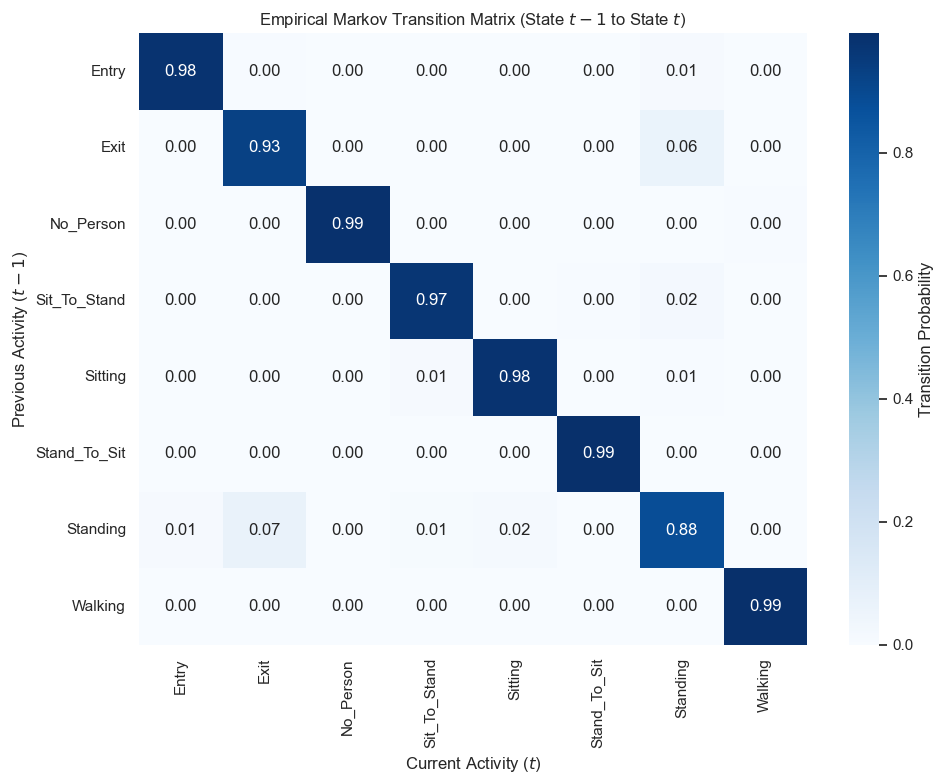


--- Starting Machine Learning Pipeline ---
Sensor Fusion: Fusing 64 features from C4001 and RD-03D.
Data Split: Train=6903, Test=1726 samples.
Training Random Forest Classifier (Optimized for Microcontroller)...

*** Overall Test Accuracy (20% Split): 98.32% ***

Classification Report (Test Set):
              precision    recall  f1-score   support

       Entry       1.00      1.00      1.00       216
        Exit       1.00      0.99      0.99       228
   No_Person       1.00      1.00      1.00       216
Sit_To_Stand       0.97      0.98      0.98       218
     Sitting       0.97      0.95      0.96       241
Stand_To_Sit       0.96      0.99      0.98       190
    Standing       0.97      0.98      0.97       202
     Walking       1.00      1.00      1.00       215

    accuracy                           0.98      1726
   macro avg       0.98      0.98      0.98      1726
weighted avg       0.98      0.98      0.98      1726


--- SCALER C++ EXPORT (COPY TO ARDUINO) ---
const

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from micromlgen import port

# Set up standard plotting parameters
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

def load_all_persons_data(folder_paths):
    """Loads CSV files from a list of specific person folders into a single DataFrame."""
    print(f"Searching for data across {len(folder_paths)} folders...")
    all_dfs = []
    
    for folder_path in folder_paths:
        folder_name = os.path.basename(folder_path)
        p_num = folder_name.replace("Person", "")
        
        file_pattern = f"P{p_num}_*.csv"
        full_pattern = os.path.join(folder_path, file_pattern)
        
        files = glob.glob(full_pattern)
        if not files:
            print(f"  -> Warning: No files found for {folder_name} using pattern {file_pattern} in {folder_path}")
            continue
            
        print(f"  -> {folder_name}: Found {len(files)} files.")
        
        for f in files:
            try:
                df = pd.read_csv(f)
                df['person_id'] = f"P{p_num}" 
                all_dfs.append(df)
            except Exception as e:
                print(f"Error reading {f}: {e}")
                
    if not all_dfs:
        print("No data loaded. Please check your folder paths.")
        return None
        
    combined_df = pd.concat(all_dfs, ignore_index=True)
    
    # Convert datetime and sort chronologically per person to maintain the Markov Sequence
    if 'datetime' in combined_df.columns:
        combined_df['datetime'] = pd.to_datetime(combined_df['datetime'], errors='coerce')
        combined_df = combined_df.sort_values(by=['person_id', 'datetime']).reset_index(drop=True)
    else:
        print("Warning: 'datetime' column not found. Sequence may not follow proper Markov flow.")
        
    return combined_df

def clean_and_handle_zeros(df):
    """Applies domain-knowledge rules while PRESERVING temporal sequence."""
    print("Cleaning data and applying domain constraints...")
    df_clean = df.copy()
    
    c4001_cols = ['c4001_distance_m', 'c4001_velocity_m_s', 'c4001_energy']
    rd_cols = ['rd_distance_mm', 'rd_velocity_cm_s', 'rd_x_mm', 'rd_y_mm', 'rd_angle_deg']
    
    cleaned_frames = []
    
    for (person, act), group in df_clean.groupby(['person_id', 'activity']):
        act_df = group.copy()
        
        if act == 'No_Person':
            cols_to_zero = c4001_cols + rd_cols
            act_df[cols_to_zero] = 0.0
            act_df['c4001_velocity_m_s_smoothed'] = 0.0
            act_df['rd_velocity_cm_s_smoothed'] = 0.0
            cleaned_frames.append(act_df)
            continue
            
        # Interpolate Dropouts
        mask_c4001_dropout = act_df['c4001_distance_m'] == 0
        act_df.loc[mask_c4001_dropout, c4001_cols] = np.nan
        
        mask_rd_dropout = act_df['rd_distance_mm'] == 0
        act_df.loc[mask_rd_dropout, rd_cols] = np.nan
        
        act_df[c4001_cols] = act_df[c4001_cols].interpolate(method='linear').bfill().ffill()
        act_df[rd_cols] = act_df[rd_cols].interpolate(method='linear').bfill().ffill()
        
        # Domain velocity constraints
        if act in ['Standing', 'Sitting']:
            act_df['c4001_velocity_m_s'] = 0.0
            act_df['rd_velocity_cm_s'] = 0.0
        elif act in ['Stand_To_Sit', 'Exit']:
            act_df['c4001_velocity_m_s'] = act_df['c4001_velocity_m_s'].clip(lower=0.0)
            act_df['rd_velocity_cm_s'] = act_df['rd_velocity_cm_s'].clip(lower=0.0)
        elif act in ['Sit_To_Stand', 'Entry']:
            act_df['c4001_velocity_m_s'] = act_df['c4001_velocity_m_s'].clip(upper=0.0)
            act_df['rd_velocity_cm_s'] = act_df['rd_velocity_cm_s'].clip(upper=0.0)
            
        act_df['c4001_velocity_m_s_smoothed'] = act_df['c4001_velocity_m_s'].rolling(window=5, center=True, min_periods=1).mean()
        act_df['rd_velocity_cm_s_smoothed'] = act_df['rd_velocity_cm_s'].rolling(window=5, center=True, min_periods=1).mean()
        
        cleaned_frames.append(act_df)
        
    final_clean_df = pd.concat(cleaned_frames, ignore_index=True)
    
    if 'datetime' in final_clean_df.columns:
        final_clean_df = final_clean_df.sort_values(by=['person_id', 'datetime']).reset_index(drop=True)
        
    return final_clean_df

def extract_sequence_features(df, window_size=50):
    """Extracts features sequentially to capture Markov transitions."""
    print(f"Extracting sequential features (window_size={window_size})...")
    features = []
    
    signals = {
        'c4_vel': 'c4001_velocity_m_s_smoothed', 'c4_dist': 'c4001_distance_m', 'c4_energy': 'c4001_energy',
        'rd_vel': 'rd_velocity_cm_s_smoothed', 'rd_dist': 'rd_distance_mm', 'rd_angle': 'rd_angle_deg',
        'rd_x': 'rd_x_mm', 'rd_y': 'rd_y_mm'
    }
    
    for person, p_group in df.groupby('person_id'):
        p_group = p_group.reset_index(drop=True)
        prev_activity = 'No_Person' # Initial state
        
        for i in range(0, len(p_group) - window_size, window_size):
            window = p_group.iloc[i:i + window_size]
            current_activity = window['activity'].mode()[0]
            
            feat_dict = {
                'person_id': person,
                'previous_activity': prev_activity, 
                'activity': current_activity        
            }
            
            for prefix, col_name in signals.items():
                series = window[col_name]
                vmin, vmax = series.min(), series.max()
                
                feat_dict.update({
                    f"{prefix}_mean": series.mean(),
                    f"{prefix}_median": series.median(),
                    f"{prefix}_std": series.std(),
                    f"{prefix}_var": series.var(),
                    f"{prefix}_rms": np.sqrt(np.mean(series**2)),
                    f"{prefix}_min": vmin,
                    f"{prefix}_max": vmax,
                    f"{prefix}_range": vmax - vmin
                })
                
            features.append(feat_dict)
            prev_activity = current_activity 
            
    return pd.DataFrame(features).fillna(0)

def visualize_markov_transitions(features_df):
    """Visualizes the empirical transition matrix to verify the Markov flow."""
    print("Generating Markov Transition Matrix...")
    transition_counts = pd.crosstab(features_df['previous_activity'], features_df['activity'])
    transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0).fillna(0)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(transition_matrix, annot=True, fmt=".2f", cmap="Blues", 
                cbar_kws={'label': 'Transition Probability'})
    plt.title("Empirical Markov Transition Matrix (State $t-1$ to State $t$)")
    plt.ylabel("Previous Activity ($t-1$)")
    plt.xlabel("Current Activity ($t$)")
    plt.tight_layout()
    plt.show()

def build_and_evaluate_model(features_df):
    """Builds ML pipeline: 80% Train, 20% Test (No Validation Set)"""
    print("\n--- Starting Machine Learning Pipeline ---")
    
    sensor_cols = [col for col in features_df.columns if col.startswith(('c4_', 'rd_'))]
    print(f"Sensor Fusion: Fusing {len(sensor_cols)} features from C4001 and RD-03D.")
    
    df_ml = features_df.copy()
    
    le_act = LabelEncoder()
    all_activities = pd.concat([df_ml['activity'], df_ml['previous_activity']]).unique()
    le_act.fit(all_activities)
    
    df_ml['activity_encoded'] = le_act.transform(df_ml['activity'])
    df_ml['prev_activity_encoded'] = le_act.transform(df_ml['previous_activity'])
    
    X = df_ml[sensor_cols + ['prev_activity_encoded']]
    y = df_ml['activity_encoded']
    
    # --- CHANGED: 80% Train, 20% Test Split. Validation Eliminated. ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
    
    print(f"Data Split: Train={X_train.shape[0]}, Test={X_test.shape[0]} samples.")
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("Training Random Forest Classifier (Optimized for Microcontroller)...")
    clf = RandomForestClassifier(
        n_estimators=20,        
        max_depth=10,            
        min_samples_split=5,    
        random_state=42, 
        n_jobs=-1
    )
    clf.fit(X_train_scaled, y_train)
    
    # Evaluate purely on the Test set now
    test_preds = clf.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, test_preds)
    
    print(f"\n" + "="*40)
    print(f"*** Overall Test Accuracy (20% Split): {test_acc * 100:.2f}% ***")
    print("="*40 + "\n")
    
    print("Classification Report (Test Set):")
    target_names = le_act.inverse_transform(sorted(y_test.unique()))
    print(classification_report(y_test, test_preds, target_names=target_names))
    
    # --- Added output for the 65 Arduino Scaler values ---
    print("\n" + "="*40)
    print("--- SCALER C++ EXPORT (COPY TO ARDUINO) ---")
    print("const float scaler_means[65] = {")
    print("  " + ", ".join([f"{x:.6f}" for x in scaler.mean_]))
    print("};")
    print("\nconst float scaler_scales[65] = {")
    print("  " + ", ".join([f"{x:.6f}" for x in scaler.scale_]))
    print("};")
    print("="*40 + "\n")

    return clf, scaler, le_act

if __name__ == "__main__":
    folder_paths = [
        r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet\Person1",
        r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet\Person2",
        r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet\Person3",
        r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet\Person4",
        r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet\Person5",
        r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet\Person6",
        r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet\Person7",
        r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet\Person8",
        r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet\Person9"
    ]
    
    base_dir = r"C:\Users\RUPAM DUTTA\Desktop\Final Dataset mmWave\Final Individual DataSet"
    
    raw_df = load_all_persons_data(folder_paths)
    
    if raw_df is not None:
        clean_df = clean_and_handle_zeros(raw_df)
        
        # CHANGED window_size from 20 to 50
        features_df = extract_sequence_features(clean_df, window_size=50)
        
        output_file = os.path.join(base_dir, "Combined_Extracted_Features_Markov_50_2.0.csv")
        try:
            features_df.to_csv(output_file, index=False)
        except PermissionError:
            timestamp = time.strftime("%Y%m%d-%H%M%S")
            fallback_file = os.path.join(base_dir, f"Combined_Extracted_Features_Markov_50_{timestamp}.csv")
            features_df.to_csv(fallback_file, index=False)
            print(f"File locked. Saved to fallback: '{fallback_file}'")
        
        visualize_markov_transitions(features_df)
        
        # This will now do 80/20 train/test split and print out the C++ arrays
        model, scaler, label_encoder = build_and_evaluate_model(features_df)
        
        print("\n--- Exporting Model to C++ ---")
        try:
            c_code = port(model)
            model_header_path = os.path.join(base_dir, "rdf_model.h")
            with open(model_header_path, "w") as f:
                f.write(c_code)
            
            file_size_mb = os.path.getsize(model_header_path) / (1024 * 1024)
            print(f"Model Header Size: {file_size_mb:.2f} MB")
            
            if file_size_mb >= 8.0:
                print("WARNING: Model exceeds 8 MB!")
            else:
                print(f"SUCCESS: Model saved to '{model_header_path}'")
        except Exception as e:
            print(f"Failed to export model to C++. Error: {e}")